In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
# โหลดข้อมูล
df = pd.read_csv('AI Job Market Dataset.csv')

# ดูข้อมูลเบื้องต้น
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


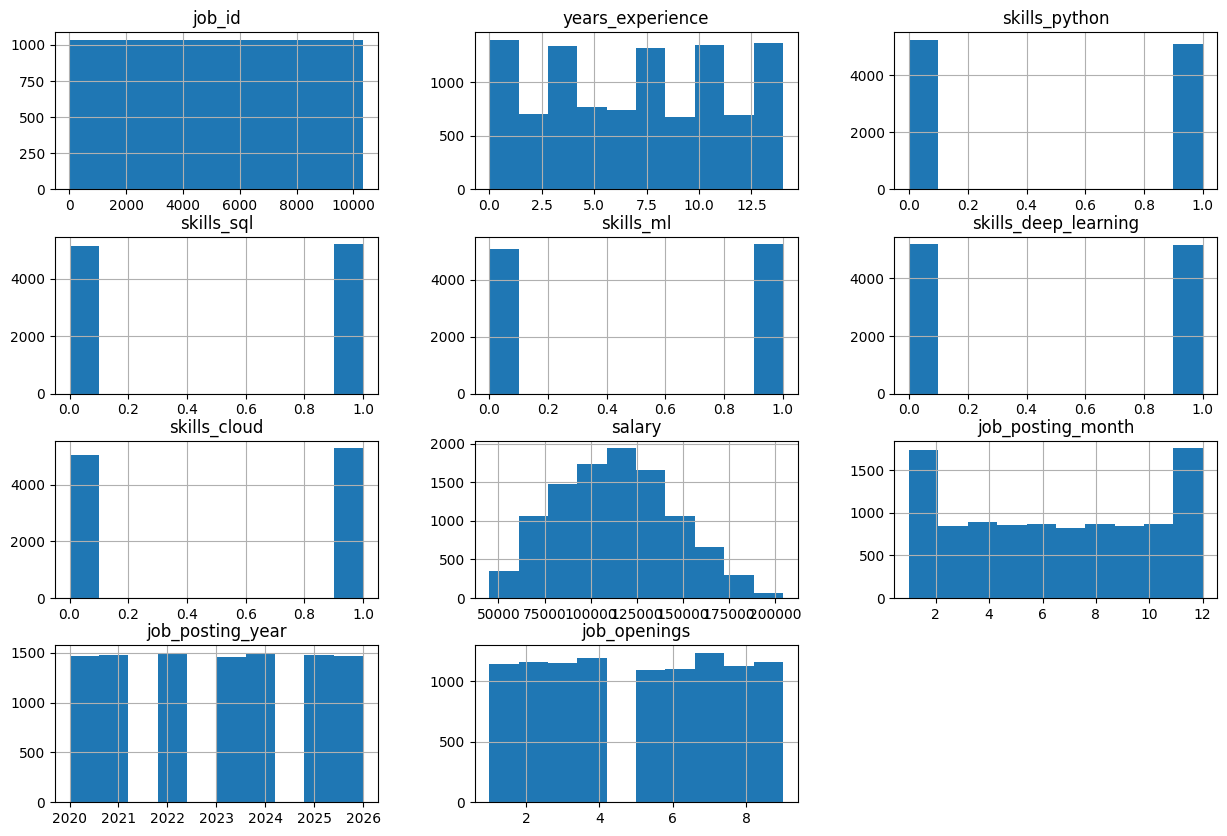

In [ ]:
df.hist(figsize=(15,10))
plt.show()

In [ ]:
df.isnull().sum()

,0
job_id,0
job_title,0
company_size,0
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,0
education_level,0
skills_python,0


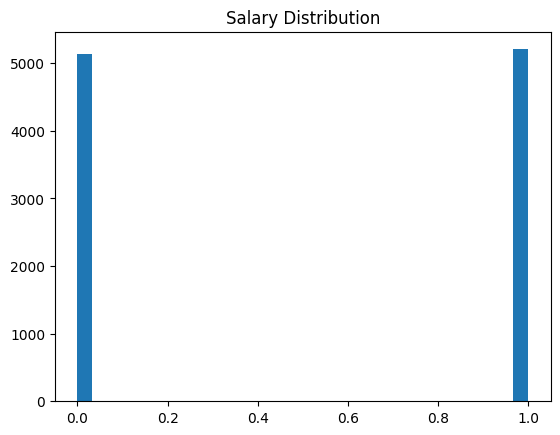

In [ ]:
plt.hist(df['skills_sql'], bins=30)
plt.title('Salary Distribution')
plt.show()

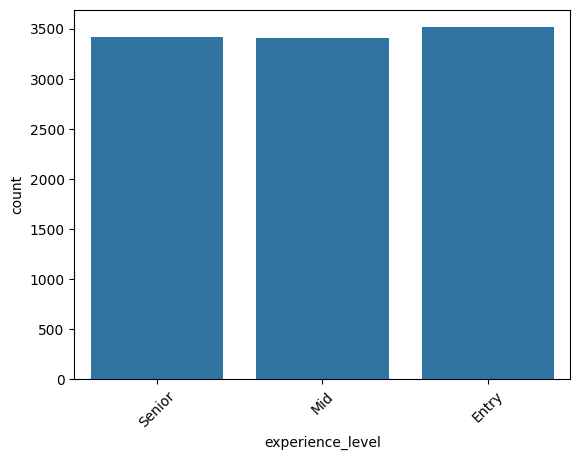

In [ ]:
sns.countplot(x='experience_level', data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
X = df.drop('salary', axis=1)
y = df['salary']

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# numeric pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])
#เลือก Model
model = RandomForestRegressor(random_state=42)
#Full Pipeline
full_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
])
#Train Model
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['job_id', 'years_experience', 'skills_python', 'skills_sql',
       'skills_ml', 'skills_deep_learning', 'skills_cloud',
       'job_posting_month', 'job_posting_year', 'job_openings'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'education_level', 'hiring_urgency'],
      dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

MAE: 2548.5474625422908
RMSE: 2998.8842651262244
R2: 0.9909678142819076


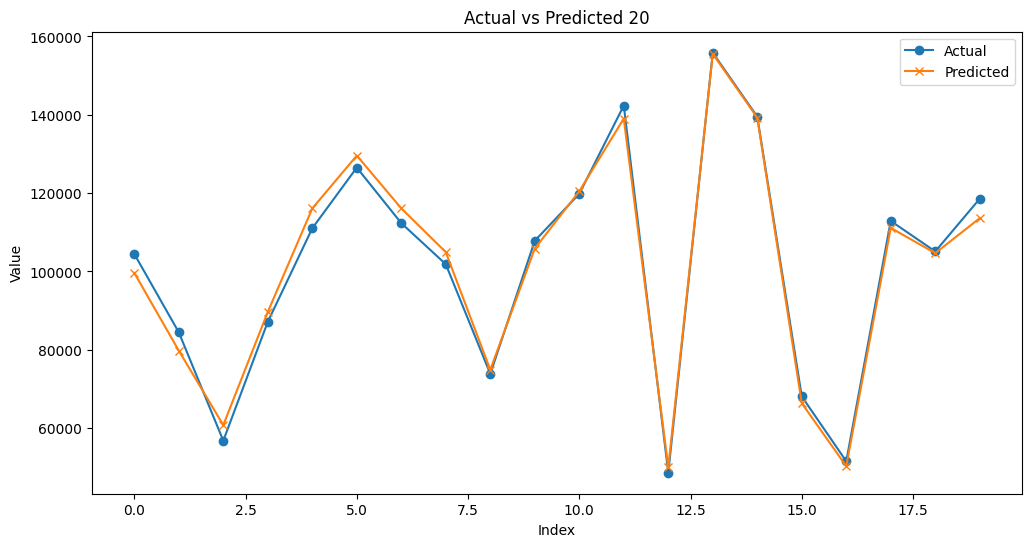

In [ ]:
#เลือก metrics ให้เหมาะสมกับข้อมูล
y_pred = full_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
n = 20  # จำนวนจุดที่จะแสดง

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:n], label='Actual', marker='o')
plt.plot(y_pred[:n], label='Predicted', marker='x')

plt.title(f'Actual vs Predicted {n}')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.show()

In [ ]:
scores = cross_val_score(
    full_pipeline, X, y,
    cv=5,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-scores)
print("RMSE per fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

RMSE per fold: [3121.99498624 3050.05356057 3104.44674814 3022.94608669 3044.87874818]
Average RMSE: 3068.864025964984


In [ ]:
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 10, 20]
}

grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)

Best Params: {'model__max_depth': 10, 'model__n_estimators': 100}
